In [20]:
# load settings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [35]:
class PlotSettings:
    COLORS = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "0.3": "#DCE3E8",
        "0.6": "#8A9AA0",
        "0.8": "#3F5C6A",
        "1.0": "#163B4A",
        "1.5": "#021518",
    }

    LINESTYLES = {"CHILDES": "-", "child": "-", "0.3": "-", "0.6": "-.", "0.8": "--", "1.0": ":", "1.5": "-"}

    # FIG_SIZE = (10, 10)

    label_fontsize = 18
    linewidth = 3

    @classmethod
    def configure_plot(cls, title=None, model=None):
        # plt.figure(figsize=cls.FIG_SIZE)

        if title or model:
            plt.title(title or model, fontsize=18, fontweight="bold")

        plt.ylim(0, 1)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.grid(True, linestyle=":", linewidth=1, color="#bbbbbb")

    @classmethod
    def configure_legend(cls):
        plt.legend(title="Settings", title_fontsize=28, fontsize=28, loc="upper left", bbox_to_anchor=(1.1, 1))

    @classmethod
    def save_figure(cls, filepath):
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()


In [23]:
# load file
data_path = "/Users/jliu/workspace/lexical_bencmark/dataset/metrics.csv"
raw_data = pd.read_csv(data_path)

In [24]:
raw_data

,Unnamed: 0,temp,dataset,month,chunk,model_type,type_token_ratio,rej_type_rate
0,0,0.3,child,6,0,LSTM,0.083600,0.062165
1,1,0.6,child,6,0,LSTM,0.188000,0.120048
2,2,1.0,child,6,0,LSTM,0.362800,0.206704
3,3,1.5,child,6,0,LSTM,0.603200,0.392626
4,0,0.3,child,6,0,trans,0.076000,0.097586
...,...,...,...,...,...,...,...,...
115,3,1.5,stela,18,1,trans,0.770897,0.144018
116,0,0.3,stela,36,0,LSTM,0.259508,0.000499
117,1,0.6,stela,36,0,LSTM,0.397675,0.006406
118,2,1.0,stela,36,0,LSTM,0.552454,0.069622


# Core metrics

In [43]:
# plot curves
df = raw_data[raw_data["temp"] == 1.0]
df = df.dropna()
# Sort by month and combine dataset + model_type for labels
df = df.sort_values("month")
df["condition"] = df["model_type"] + "(" + df["dataset"] + ")"


def plot_curves(df, x_header: str, y_header: str) -> None:
    PlotSettings.configure_plot()

    # Calculate mean and confidence intervals
    df_stats = df.groupby(["condition", x_header])[y_header].agg(["mean", "std", "count"]).reset_index()
    df_stats["ci"] = 1.96 * df_stats["std"] / np.sqrt(df_stats["count"])

    unique_conditions = df_stats["condition"].unique()
    extra_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_conditions)))
    color_dict = {cond: PlotSettings.COLORS.get(cond, extra_colors[i]) for i, cond in enumerate(unique_conditions)}

    for condition in unique_conditions:
        subset = df_stats[df_stats["condition"] == condition]
        plt.plot(
            subset[x_header],
            subset["mean"],
            label=condition,
            color=color_dict[condition],
            linestyle=PlotSettings.LINESTYLES.get(condition.split("(")[0], "-"),
            linewidth=PlotSettings.linewidth,
        )
        plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color_dict[condition], alpha=0.2)

    plt.xlabel(x_header, fontsize=PlotSettings.label_fontsize)
    plt.ylabel(y_header, fontsize=PlotSettings.label_fontsize)
    PlotSettings.configure_legend()


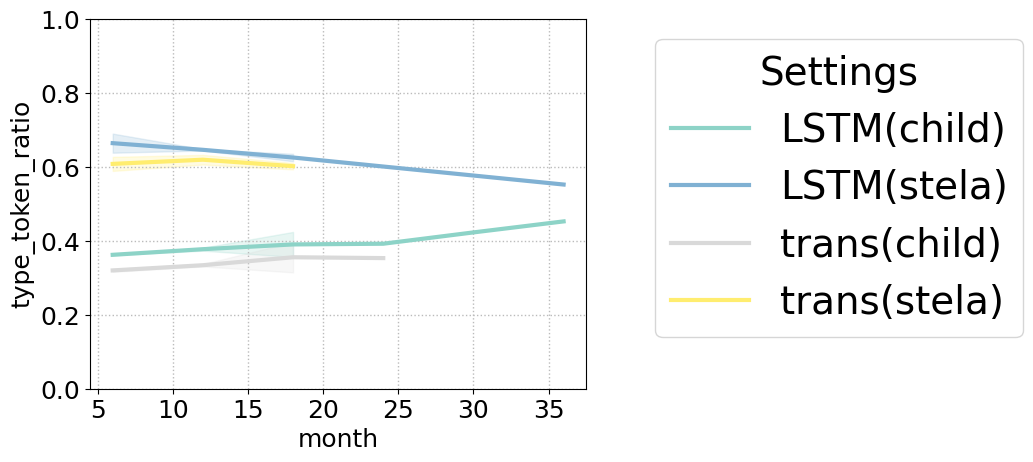

In [41]:
# Usage
x_header = "month"
y_header = "type_token_ratio"
fig = plot_curves(df, x_header, y_header)

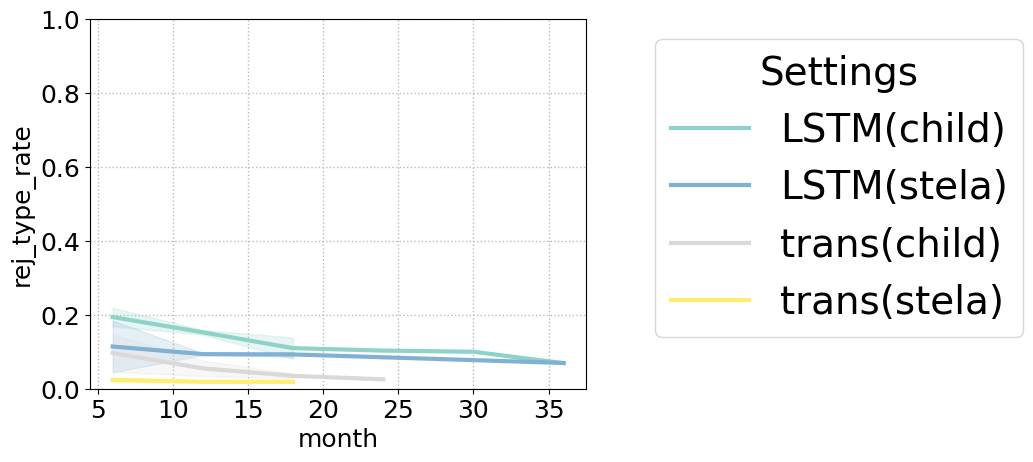

In [42]:
# Usage
x_header = "month"
y_header = "rej_type_rate"
fig = plot_curves(df, x_header, y_header)

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


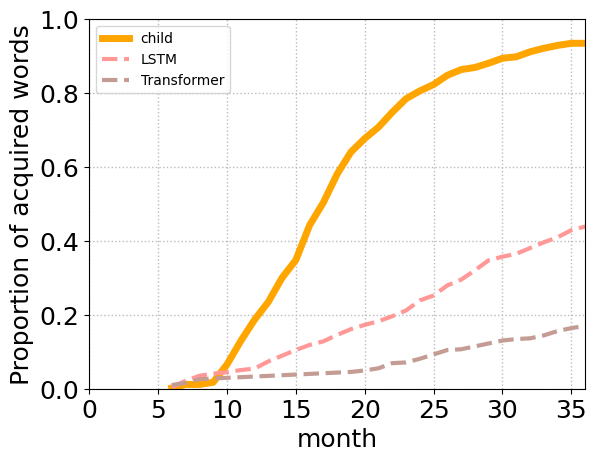

<Figure size 640x480 with 0 Axes>

In [10]:
# CDI metrics
threshold = 400
month_range = [6, 36]
lang = "AE"

test_set = "audiobook"
scale = 1
plot_CDI(threshold, month_range, lang, test_set)

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


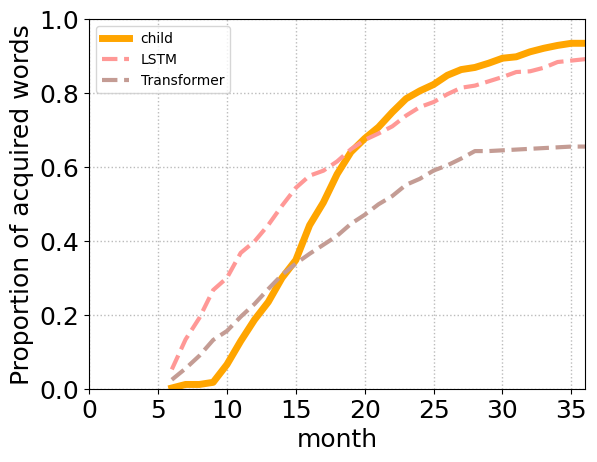

<Figure size 640x480 with 0 Axes>

In [14]:
test_set = "adult"
plot_CDI(threshold, month_range, lang, test_set)

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


<class 'list'>
<class 'list'>
<class 'list'>


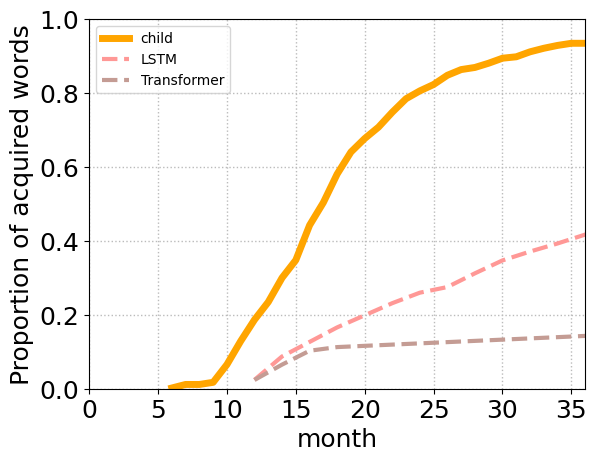

<Figure size 640x480 with 0 Axes>

In [34]:
test_set = "audiobook"
plot_CDI(threshold, month_range, lang, test_set)

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


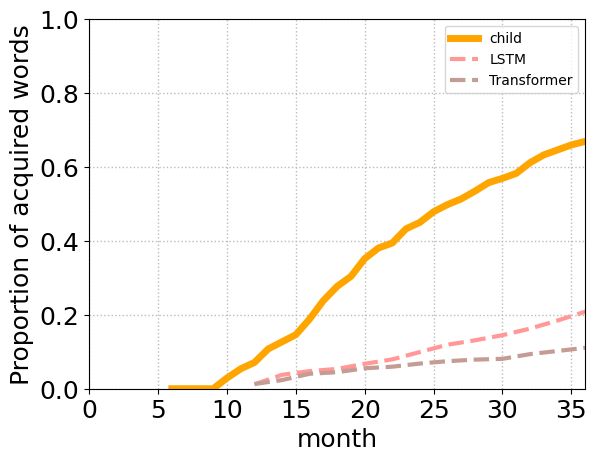

<Figure size 640x480 with 0 Axes>

In [23]:
threshold = 300
test_set = "audiobook_400"
plot_CDI(threshold, month_range, lang, test_set)

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


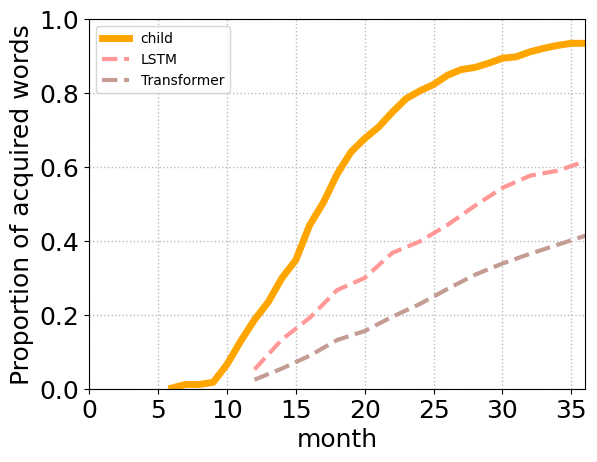

<Figure size 640x480 with 0 Axes>

In [24]:
threshold = 60
test_set = "adult"
plot_CDI(threshold, month_range, lang, test_set)

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


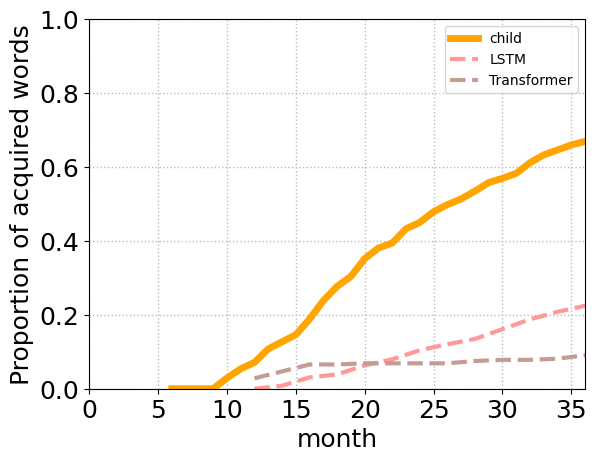

<Figure size 640x480 with 0 Axes>

In [25]:
threshold = 300
test_set = "adult_400"
plot_CDI(threshold, month_range, lang, test_set)

### Nonword rates

In [287]:
out_ROOT = "/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/month_count/nword_ttr"


In [95]:
my_list = [10, 20, 30, 40]
new_value = 100

# Change the first element
my_list[0] = new_value

print(my_list)


[100, 20, 30, 40]


In [23]:
# load and plot the curve iteratively
PROMPT = "unprompted"
temp = 1.0


def plot_line(child_stats, header: str, label: str, color: str, linewidth=2.5, linestyle="--", scale=1):
    month_lst = list(child_stats.index)
    if scale != 1:
        # change the first datapoint
        month_lst[0] = 6

    elif scale == 1:
        # change the first datapoint
        month_lst[0] = 6
    print(month_lst)
    plt.plot(month_lst, child_stats[header], label=label, color=color, linewidth=linewidth, linestyle=linestyle)
    # save the file in the given directory
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle=":", linewidth=1, color="#bbbbbb")
    plt.xlabel("Month", fontsize=18)
    plt.ylabel(header, fontsize=18)
    plt.xlim([0, 36])
    plt.ylim([0, 1])
    plt.legend()


def plot_trend(header, test_set, PROMPT, temp, name, scale=1):
    # plot CHILDES stat in a fixed folder
    stat_frame = pd.read_csv(Path(out_ROOT) / "audiobook" / "CHILDES" / "stat.csv")
    stat_frame.set_index("month", inplace=True)
    label = "child"
    plot_line(stat_frame, header, "child", color=color_dict[label], linewidth=3.5, linestyle="-", scale=1)

    MODEL = "LSTM"
    stat_frame = pd.read_csv(Path(out_ROOT) / test_set / PROMPT / MODEL / f"unprompted_{temp}" / "stat.csv")
    stat_frame.set_index("month", inplace=True)
    plot_line(stat_frame, header, MODEL, color=color_dict[MODEL], scale=scale)

    MODEL = "Transformer"
    label = f"{PROMPT}_{MODEL}"
    stat_frame = pd.read_csv(Path(out_ROOT) / test_set / PROMPT / MODEL / f"unprompted_{temp}" / "stat.csv")
    stat_frame.set_index("month", inplace=True)
    plot_line(stat_frame, header, MODEL, color=color_dict[MODEL], scale=scale)

    # plt.legend(title='Models', title_fontsize=28, fontsize=28, loc='upper left', bbox_to_anchor=(1.1, 1))
    plt.legend()
    plt.savefig(fig_ROOT / name, dpi=300, bbox_inches="tight")

In [311]:
out_ROOT = "/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/500h/nword_ttr"

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


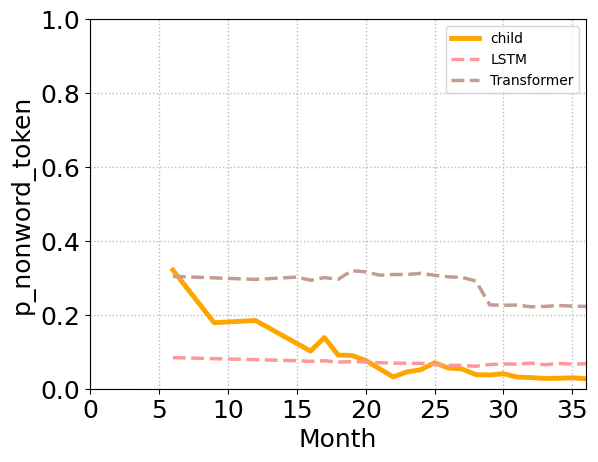

In [315]:
PROMPT = "unprompted"
header = "p_nonword_token"
test_set = "adult"
name = test_set + "_500_nonword_token.png"
scale = 0.5
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


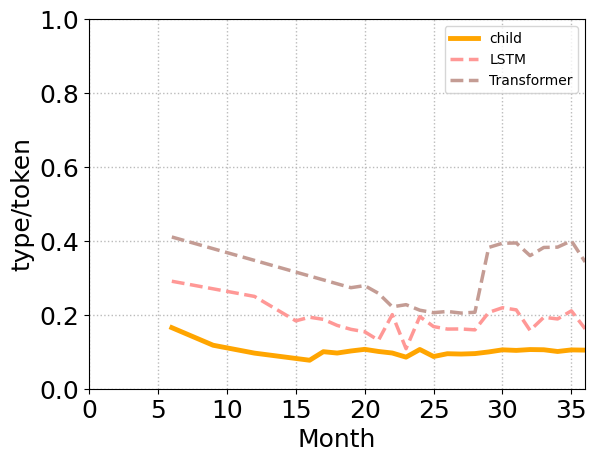

In [318]:
PROMPT = "unprompted"
header = "type/token"
test_set = "audiobook"
name = test_set + f"_500_ttr.png"
scale = 0.5
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


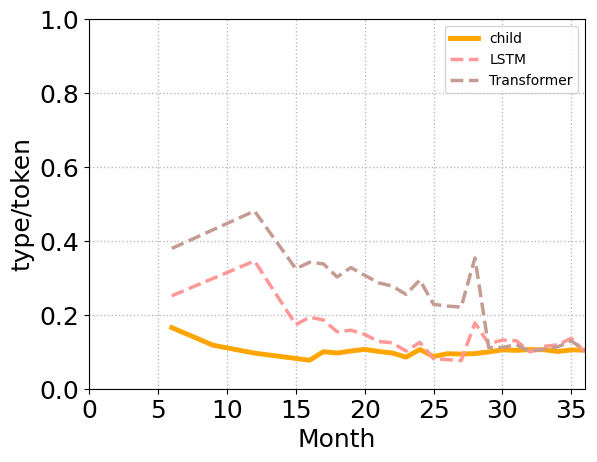

In [317]:
PROMPT = "unprompted"
header = "type/token"
test_set = "adult"
name = test_set + f"_500_ttr.png"
scale = 0.5
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


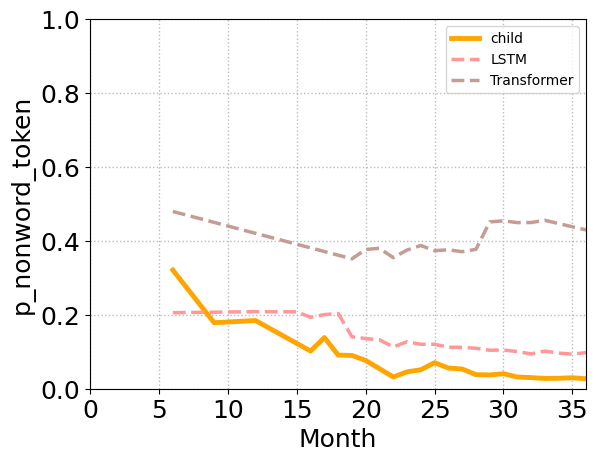

In [292]:
PROMPT = "unprompted"
header = "p_nonword_token"
test_set = "audiobook"
name = test_set + "_core_nonword_token.png"
scale = 1
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


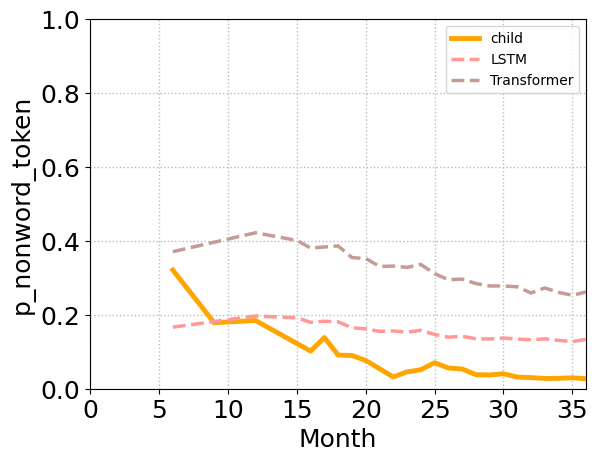

In [293]:
PROMPT = "unprompted"
header = "p_nonword_token"
test_set = "audiobook_400"
name = test_set + "_core_nonword_token_400.png"
scale = 0.5
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


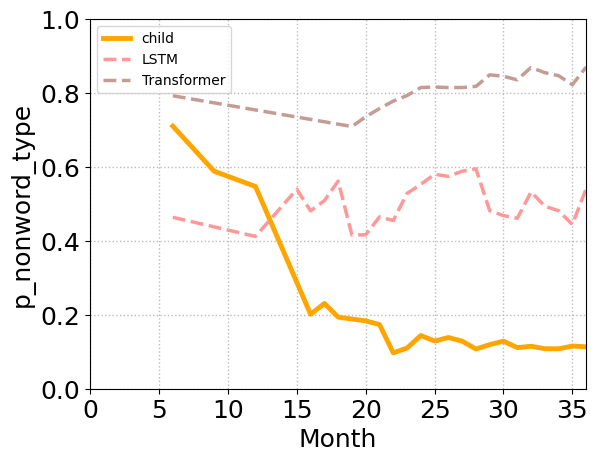

In [294]:
PROMPT = "unprompted"
header = "p_nonword_type"
test_set = "audiobook"
name = test_set + "_core_nonword_type.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


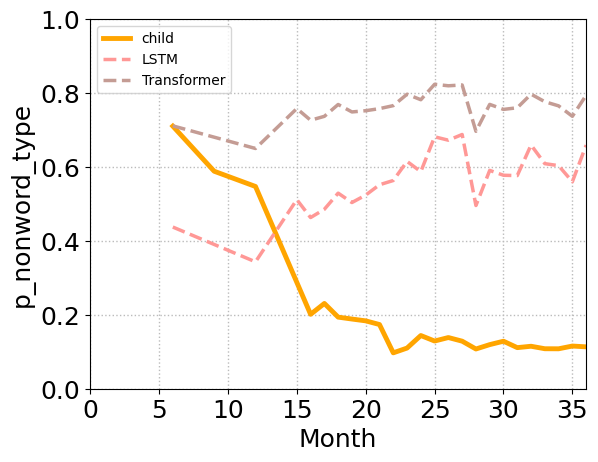

In [295]:
PROMPT = "unprompted"
header = "p_nonword_type"
test_set = "audiobook_400"
name = test_set + "_core_nonword_type_400.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


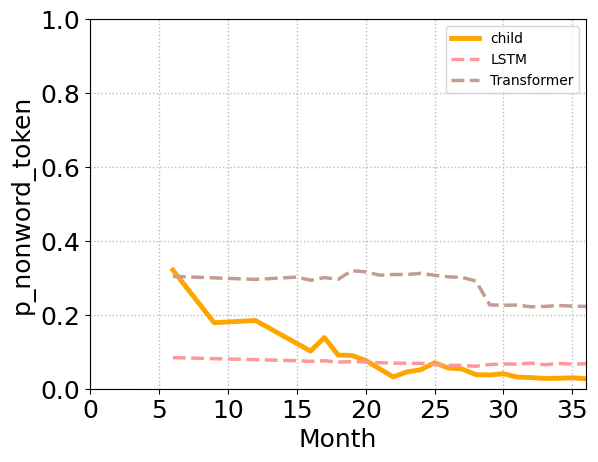

In [296]:
header = "p_nonword_token"
test_set = "adult"
name = test_set + "_core_nonword_token.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)


[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


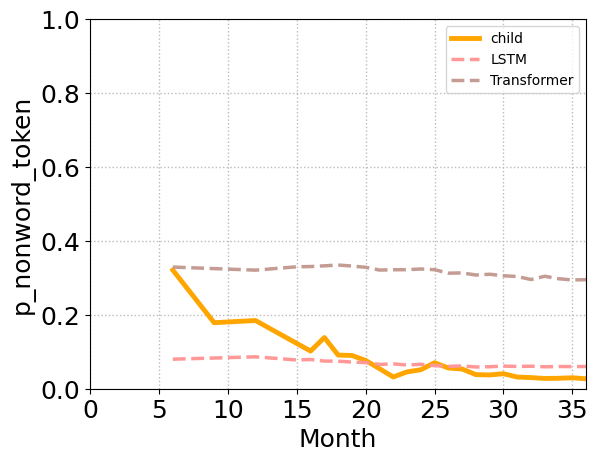

In [297]:
header = "p_nonword_token"
test_set = "adult_400"
name = test_set + "_core_nonword_token_400.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


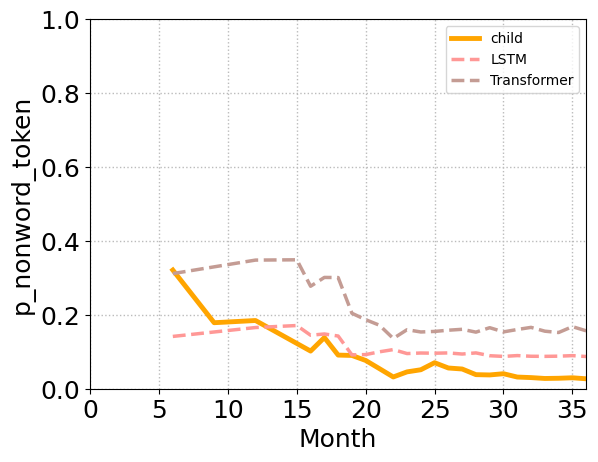

In [298]:
header = "p_nonword_token"
test_set = "audiobook"
PROMPT = "prompted"
name = test_set + "_core_nonword_token.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)


[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


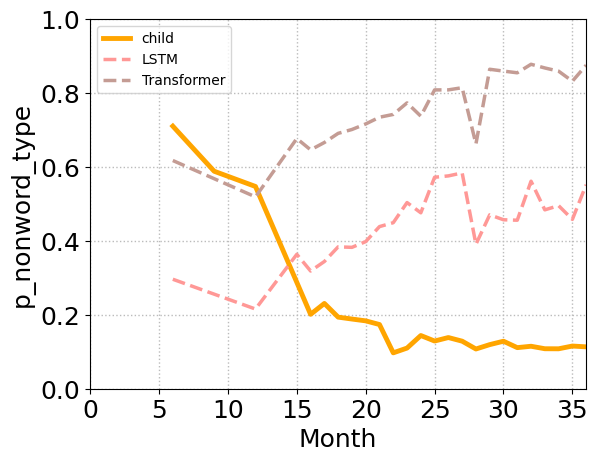

In [299]:
header = "p_nonword_type"
test_set = "adult"
PROMPT = "unprompted"
scale = 0.5
name = test_set + "_core_nonword_type.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


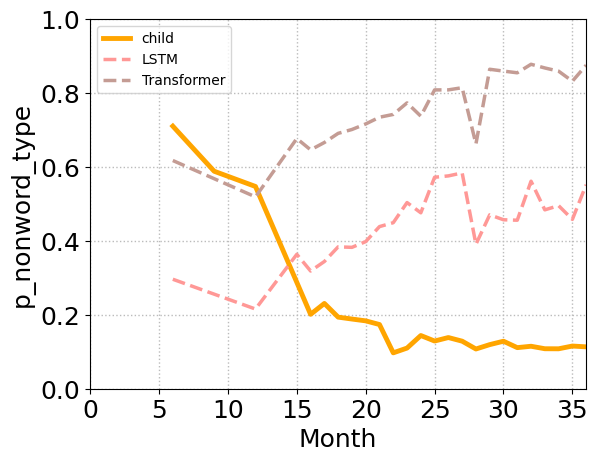

In [300]:
header = "p_nonword_type"
test_set = "adult"
PROMPT = "unprompted"
scale = 1
name = test_set + "_core_nonword_type.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/month_count/nword_ttr/adult_400/prompted/LSTM/unprompted_1.0/stat.csv'

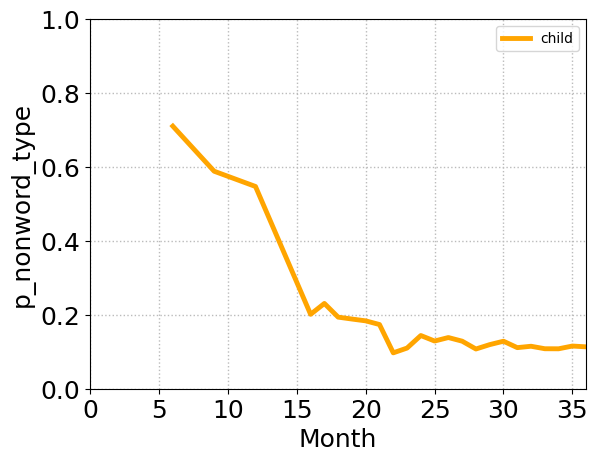

In [304]:
header = "p_nonword_type"
test_set = "adult_400"
PROMPT = "prompted"
name = test_set + "_core_nonword_type_400.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

In [303]:
header = "p_nword_type"
test_set = "adult"
PROMPT = "unprompted"
name = test_set + "_core_nonword_type.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


KeyError: 'p_nword_type'

In [122]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [124]:
def plot_sigmoid(CDI_path: Path, word_freq_path: Path, score_dir: Path, month_range: list, threshold: int, n_bins: int, target_y: int, genset_label, fig_path, title):
    # load files
    word_freq = pd.read_csv(word_freq_path)
    if genset_label == "human_CDI":
        all_score = pd.read_csv(CDI_path)
        all_score.set_index("word", inplace=True)
        all_score = all_score.loc[:, str(AGE_DICT[lang][0]) : str(AGE_DICT[lang][1])]
    else:
        all_score = load_csv(score_dir, str(month_range[0]), str(month_range[1]))
    frame = pd.read_csv(CDI_path)
    frame = get_equal_quantity(frame, "count", n_bins)
    frame_grouped = frame.groupby("group")

    para_all = pd.DataFrame()
    for _, frame_group in frame_grouped:
        # select the corresponding words
        score = all_score[all_score.index.isin(frame_group["word"])]
        # get log median freq of each bands
        # m_freq = np.log10(word_freq[word_freq['word'].isin(frame_group['word'])]['freq_m'].median())
        m_freq = word_freq[word_freq["word"].isin(frame_group["word"])]["freq_m"].median()
        # apply threhsold if not reported by human
        if not genset_label == "human_CDI":
            score = apply_threshold(score, threshold)
        merged = merge_score(score)
        para = fit_sigmoid(merged, target_y, f"{m_freq:.2f}")
        para_all = pd.concat([para_all, para])

    # save the file to the directory
    plt.grid(True)
    plt.xlabel("Estimated months", fontsize=20)
    plt.ylabel("Estimated months", fontsize=20)
    plt.title(f"{title}", fontsize=19, fontweight="bold")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(fontsize=11)
    plt.show()
    para_all["gen_set"] = genset_label
    return para_all


In [120]:
freq_ROOT = "/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/month_count/CDI"


# the modified function
# the wrapper func to plot all figures
def plot_all_freq(lang: str, model: str, prompt_type: str, fig_path: str):
    para_all = pd.DataFrame()
    # estimate human vocab growth: human_CDI and CHILDES

    title = f"{lang} vocab growth"
    test_set = "human"
    word_freq_path = Path(train_ROOT) / "CHILDES_adult.csv"
    CDI_path = Path(CDI_ROOT) / f"{lang}_exp_{test_set}.csv"
    score_dir = CDI_path

    # estimate CHILDES vocab growth
    score_dir = Path(freq_ROOT) / "CHILDES" / lang / "content.csv"
    fig_dir = fig_path / f"{lang}_CHILDES.png"
    para = plot_sigmoid(CDI_path, word_freq_path, score_dir, month_range, threshold, n_bins, target_y, "child production", fig_dir, title)
    para_all = pd.concat([para_all, para])

    # estimate machine vocab growth: accumulator, crp and LM generation
    test_set = "machine"
    CDI_path = Path(CDI_ROOT) / f"{lang}_exp_{test_set}.csv"
    word_freq_path = Path(train_ROOT) / "3200h.csv"

    temp_lst = [0.3, 0.6, 1.0, 1.5]
    for temp in temp_lst:
        score_dir = Path(freq_ROOT) / "audiobook" / prompt_type / model / lang / f"unprompted_{str(temp)}.csv"
        fig_dir = fig_path / f"{lang}_{prompt_type}_{model}_{str(temp)}.png"
        title = f"{prompt_type} generations by {model}"

        para = plot_sigmoid(CDI_path, word_freq_path, score_dir, month_range, threshold, n_bins, target_y, temp, fig_dir, title)
        para_all = pd.concat([para_all, para])

    # save the results to the fig dir
    plot_lines(para_all, prompt_type, model, linestyle="--")  # plot_log(para_all)
    fig_dir = fig_path / f"{lang}_{prompt_type}_{model}.png"
    plt.savefig(fig_dir, dpi=300, bbox_inches="tight")
    return para_all

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[12, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[12, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


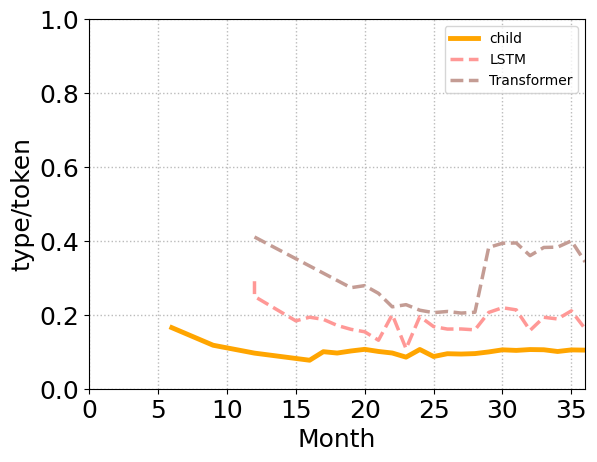

In [117]:
PROMPT = "unprompted"
header = "type/token"
test_set = "audiobook"
scale = 0.5
name = test_set + "_core_ttr.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


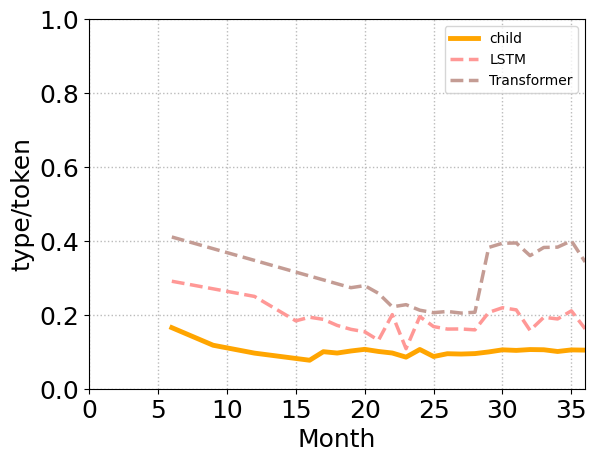

In [118]:
PROMPT = "unprompted"
header = "type/token"
test_set = "audiobook"
scale = 1
name = test_set + "_core_ttr.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

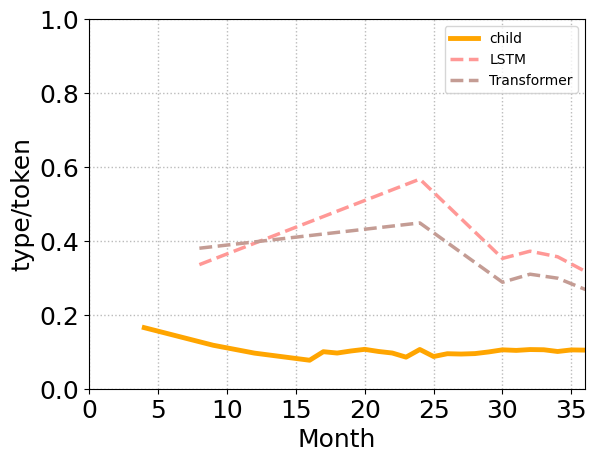

In [52]:
PROMPT = "unprompted"
header = "type/token"
test_set = "audiobook_400"
name = test_set + "_core_ttr_400.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

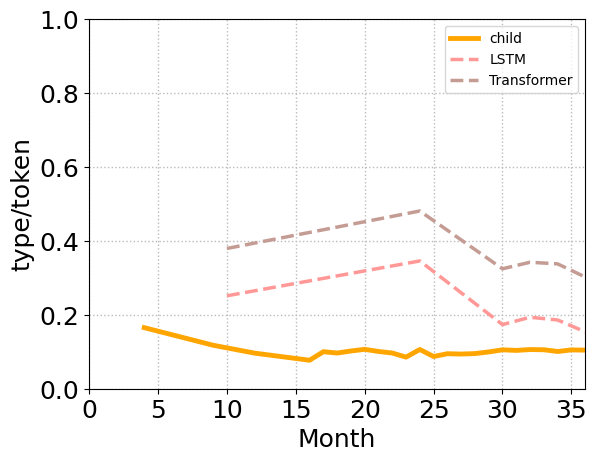

In [53]:
PROMPT = "unprompted"
header = "type/token"
test_set = "adult"
name = test_set + "_core_ttr.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

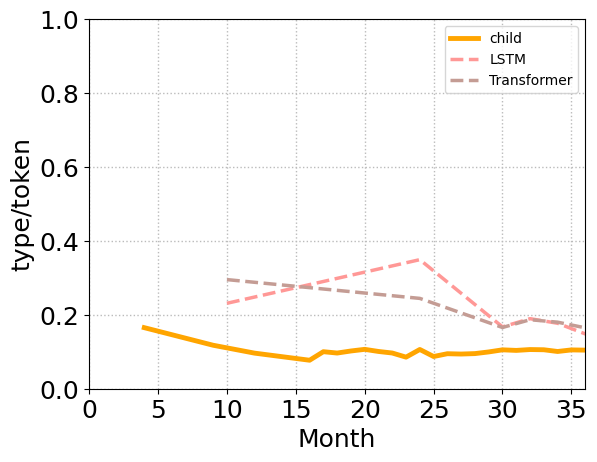

In [54]:
PROMPT = "unprompted"
header = "type/token"
test_set = "adult_400"
name = test_set + "_core_ttr_400.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[12, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[12, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


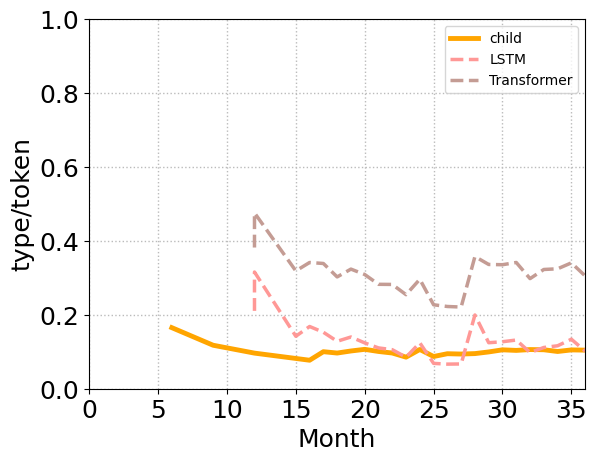

In [119]:
header = "type/token"
PROMPT = "prompted"
test_set = "adult"
scale = 0.5
name = test_set + "_core_ttr.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

[6, 9, 12, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
[6, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


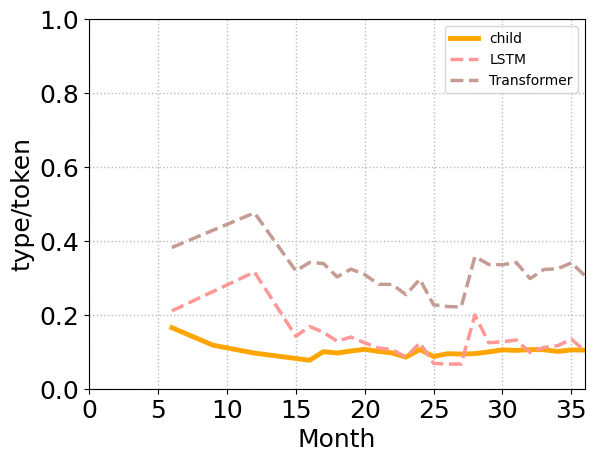

In [120]:
header = "type/token"
PROMPT = "prompted"
test_set = "adult"
scale = 1
name = test_set + "_core_ttr.png"
plot_trend(header, test_set, PROMPT, temp, name, scale=scale)

# Setting 1: Temperature in different settings

### Machine CDI 

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/500h/unprompted/LSTM/AE'

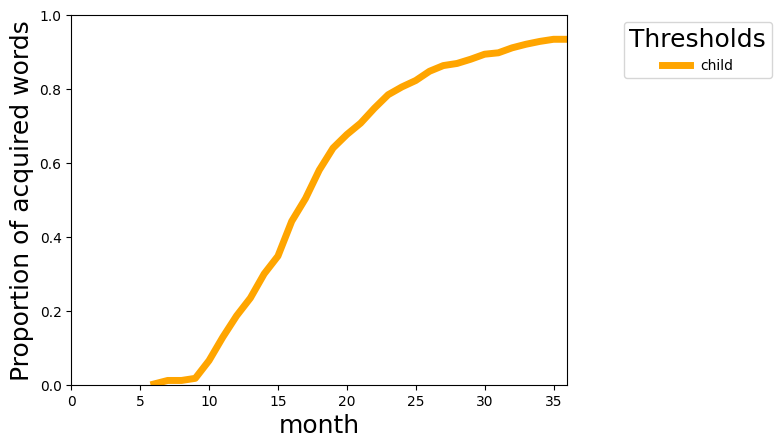

In [29]:
threshold = 60
month_range = [6, 36]
lang = "AE"
prompt_type = "unprompted"
crp_path = Path(gen_ROOT) / "crp"

model = "LSTM"
fig_path = fig_ROOT / "temp_CDI_LSTM.png"
plot_all(fig_path, lang, threshold, model, prompt_type, month_range)


model = "Transformer"
model[:4]
fig_path = fig_ROOT / "temp_CDI_Trans.png"
plot_all(fig_path, lang, threshold, model, prompt_type, month_range)


### Nonword rates

In [30]:
PROMPT = "unprompted"


def plot_nword_temp(MODEL: str, header: str, out_ROOT: str, PROMPT: str, header_suffix=False):
    stat_frame = pd.read_csv(Path(out_ROOT) / "CHILDES" / "stat.csv")
    stat_frame.set_index("month", inplace=True)
    label = "child"
    plot_line(stat_frame, header, "child", color=color_dict[label], linewidth=3.5, linestyle="-")

    temp_lst = ["0.3", "0.6", "1.0", "1.5"]
    for temp in temp_lst:
        stat_frame = pd.read_csv(Path(out_ROOT) / PROMPT / MODEL / f"unprompted_{temp}" / "stat.csv")
        stat_frame.set_index("month", inplace=True)
        plot_line(stat_frame, header, temp, color=color_dict[temp], linestyle=linestyle_dict[temp])

    if not header_suffix:
        header_suffix = "nword_" + header.split("_")[-1]  # only get the header suffix
    plt.title(MODEL, fontsize=18, fontweight="bold")
    plt.legend(title="Settings", title_fontsize=28, fontsize=28, loc="upper left", bbox_to_anchor=(1.1, 1))
    plt.savefig(fig_ROOT / f"temp_{header_suffix}_{MODEL[:5]}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.clf()

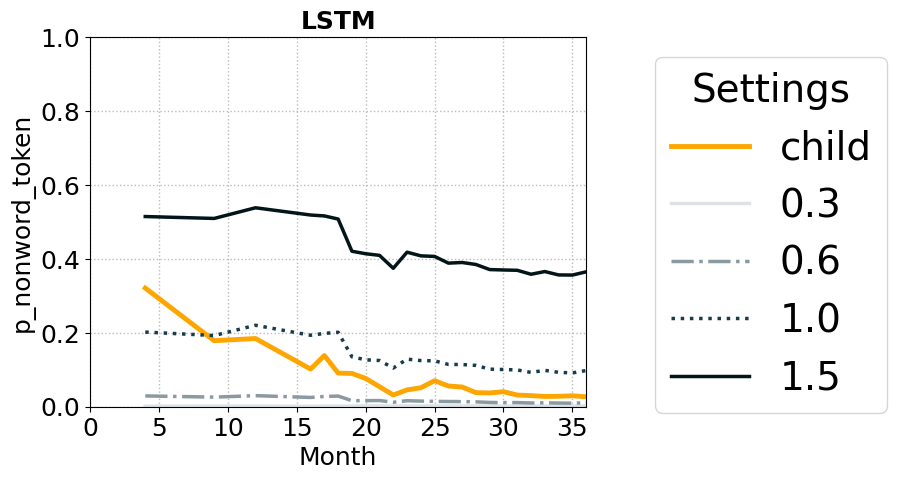

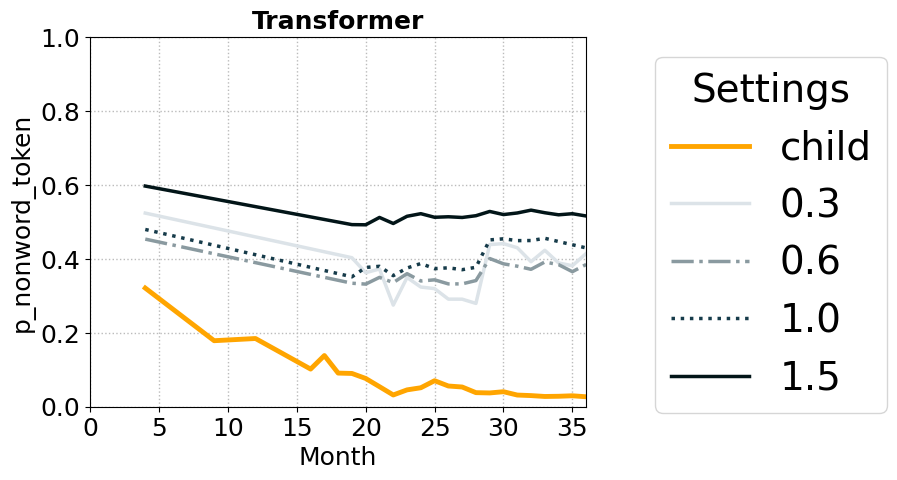

<Figure size 640x480 with 0 Axes>

In [5]:
header = "p_nonword_token"
plot_nword_temp("LSTM", header, out_ROOT, PROMPT)
plot_nword_temp("Transformer", header, out_ROOT, PROMPT)


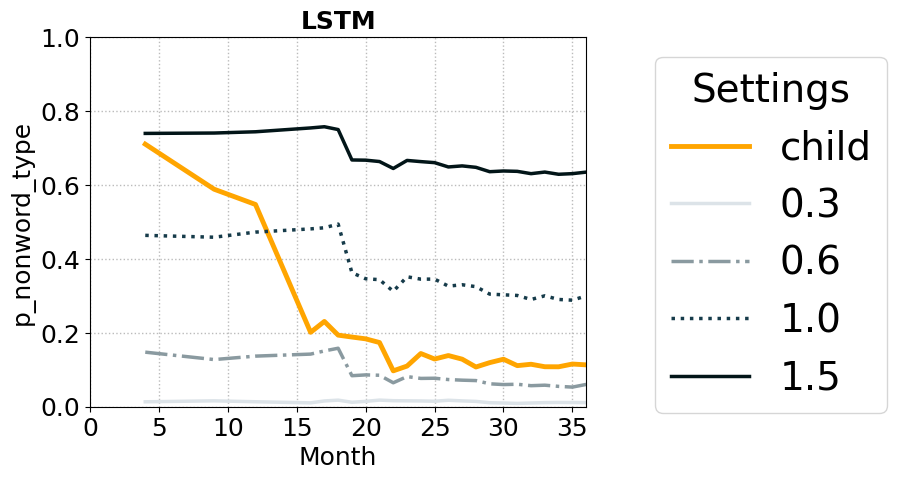

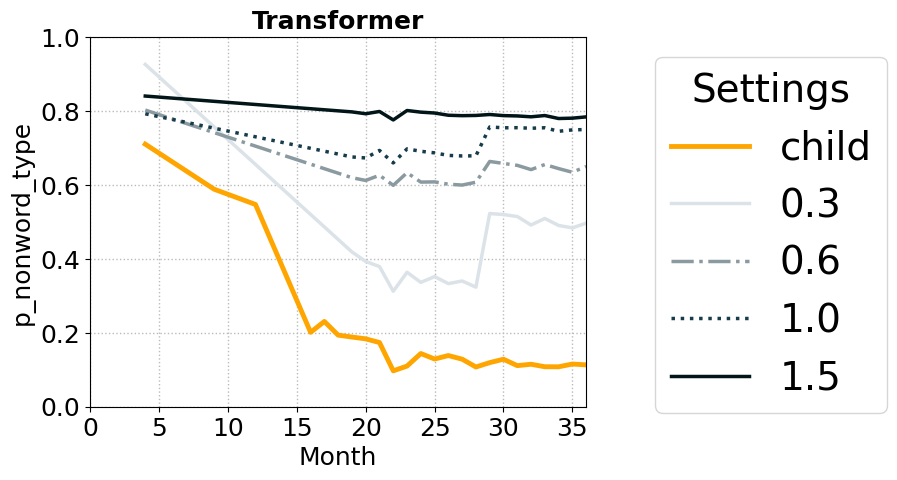

<Figure size 640x480 with 0 Axes>

In [31]:
header = "p_nonword_type"
plot_nword_temp("LSTM", header, out_ROOT, PROMPT)
plot_nword_temp("Transformer", header, out_ROOT, PROMPT)

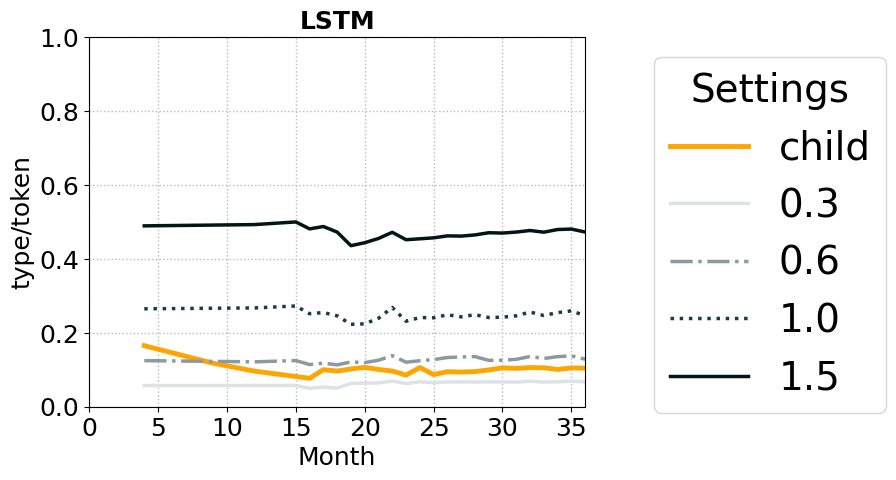

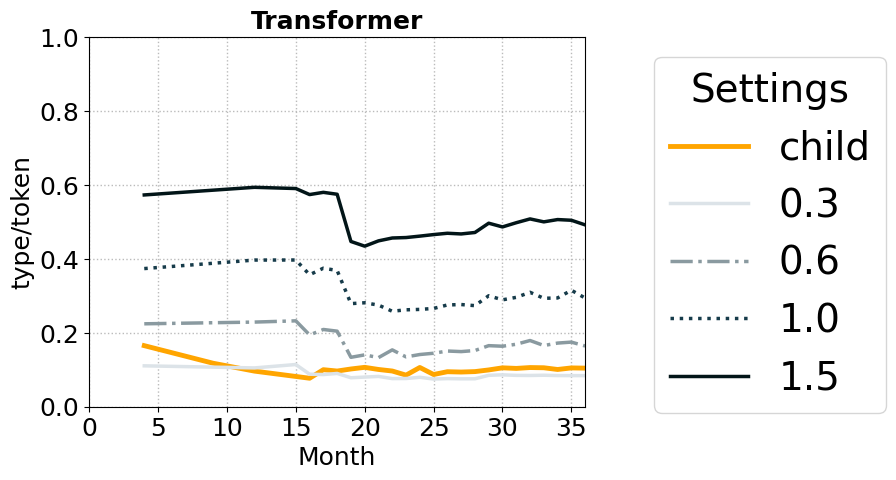

<Figure size 640x480 with 0 Axes>

In [32]:
header = "type/token"
PROMPT = "prompted"
plot_nword_temp("LSTM", header, out_ROOT, PROMPT, "ttr")
plot_nword_temp("Transformer", header, out_ROOT, PROMPT, "ttr")

# Setting 2: Temperature trade-off 

In [59]:
# load data
n_bins = 100
target_y = 0.8


def get_CDI(df_path, month_range, mean=False):
    df = load_csv(df_path, str(month_range[0]), str(month_range[1]))
    score = apply_threshold(df, threshold)
    # convert the result into dict keys
    if mean == True:
        CDI = merge_score(score).T.mean().item()
    else:
        CDI = merge_score(score)[36].item()
    return CDI


def get_stat(df_path, mean=False):
    # get the nword rate and ttr
    if mean == True:
        stat_frame = pd.read_csv(df_path)
        nword = stat_frame["p_nonword_type"].mean().item()
        ttr = stat_frame["type/token"].mean().item()

    else:
        stat_frame = pd.read_csv(df_path).tail(1)
        nword = stat_frame["p_nonword_type"].item()
        ttr = stat_frame["type/token"].item()
    return nword, ttr


# get the slope
def cal_slope(train_ROOT, CDI_ROOT, prompt_type, lang, model, temp, test_set, month_range=month_range, threshold=threshold, n_bins=n_bins, target_y=target_y):
    """get slope and starting month given a df"""
    # get sigmoid reuslts
    CDI_path = Path(CDI_ROOT) / f"{lang}_exp_{test_set}.csv"

    if test_set == "human":
        word_freq_path = Path(train_ROOT) / "CHILDES_adult.csv"
        score_dir = CDI_path
        # estimate CHILDES vocab growth
        score_dir = Path(freq_ROOT) / "CHILDES" / lang / "content.csv"
        print(score_dir)
    else:
        word_freq_path = Path(train_ROOT) / "3200h.csv"
        score_dir = Path(freq_ROOT) / "CDI" / "audiobook" / prompt_type / model / lang / f"unprompted_{str(temp)}.csv"

    para = plot_sigmoid(CDI_path, word_freq_path, score_dir, month_range, threshold, n_bins, target_y, temp, plot_fig=False)
    para = para.sort_values(by="Group", ascending=True)
    # get slope
    slope = (para["Month"].tolist()[5] - para["Month"].tolist()[0]) / 6

    return slope


def get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean):
    """get all scores to be tested"""
    score_all = pd.DataFrame()

    # loop over each temp
    for MODEL in MODEL_lst:
        # get the slope df
        for temp in temp_lst:
            # get the CDI score
            filename = "unprompted_" + str(temp) + ".csv"
            df_path = Path(freq_ROOT) / "CDI" / "audiobook" / PROMPT / MODEL / lang / filename
            CDI = get_CDI(df_path, month_range, mean=mean)
            # slope = cal_slope(train_ROOT,CDI_ROOT,PROMPT,lang,MODEL,temp,'machine')
            # get the nword rate and ttr
            df_path = Path(out_ROOT) / "prompted" / MODEL / f"unprompted_{temp}" / "stat.csv"
            nword, ttr = get_stat(df_path, mean)
            score_frame = pd.DataFrame([MODEL, temp, CDI, nword, ttr]).T
            score_all = pd.concat([score_frame, score_all])

    # add child datapoint
    df_path = Path(freq_ROOT) / "CHILDES" / lang / "content.csv"
    child_CDI = get_CDI(df_path, month_range, mean=mean)

    df_path = Path(out_ROOT) / "CHILDES" / "stat.csv"
    nword, ttr = get_stat(df_path, mean)
    # slope = cal_slope(train_ROOT,CDI_ROOT,PROMPT,lang,MODEL,0,'human')
    score_frame = pd.DataFrame(["child", 0, child_CDI, nword, ttr]).T
    # add adult datapoint
    adult_CDI = 1
    # normalize the adult reference utterance
    score_all = pd.concat([score_all, score_frame])
    score_all.columns = ["model", "temp", "CDI", "p_nonword_type", "type/token"]
    # sort the results by temp
    score_all = score_all.sort_values("temp")

    return score_all


def get_score_all1(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set):
    """get all scores to be tested"""
    score_all = pd.DataFrame()

    # loop over each temp
    for MODEL in MODEL_lst:
        # get the slope df
        for temp in temp_lst:
            # get the CDI score
            filename = "unprompted_" + str(temp) + ".csv"
            df_path = Path(freq_ROOT) / "CDI" / train_set / PROMPT / MODEL / lang / filename
            CDI = get_CDI(df_path, month_range, mean=mean)

            # get the nword rate and ttr
            df_path = Path(out_ROOT) / "prompted" / MODEL / f"unprompted_{temp}" / "stat.csv"
            nword, ttr = get_stat(df_path, mean)
            score_frame = pd.DataFrame([MODEL, temp, CDI, nword, ttr]).T
            score_all = pd.concat([score_frame, score_all])

    # add child datapoint
    df_path = Path(freq_ROOT) / "CHILDES" / lang / "content.csv"
    child_CDI = get_CDI(df_path, month_range, mean=mean)

    df_path = Path(out_ROOT) / "CHILDES" / "stat.csv"
    nword, ttr = get_stat(df_path, mean)

    score_frame = pd.DataFrame(["child", 0, child_CDI, nword, ttr]).T
    # add adult datapoint
    adult_CDI = 1
    # normalize the adult reference utterance
    score_all = pd.concat([score_all, score_frame])
    score_all.columns = ["model", "temp", "CDI", "p_nonword_type", "type/token"]
    # sort the results by temp
    score_all = score_all.sort_values("temp")

    return score_all


# plot out the results
def temp_tradeoff(metric: str, name: str, train_set, mean, y_lim=[0, 1]):
    for MODEL in MODEL_lst:
        frame = score_all[score_all["model"] == MODEL]
        # plot out the figures
        plt.plot(frame["CDI"], frame[metric], marker="o", linestyle="--", color=color_dict[MODEL], label=MODEL)
        # Add labels next to each dot
        for x, y, label in zip(frame["CDI"], frame[metric], frame["temp"]):
            plt.text(x, y, label, fontsize=12, ha="right", va="bottom")
    # Show legend for lines
    plt.legend()

    # plot the adult and child
    frame = score_all[score_all["model"] == "child"]
    plt.scatter(frame["CDI"], frame[metric], marker="o", linestyle="--", color=color_dict["child"], label="child")
    # Add labels next to each dot
    for x, y in zip(frame["CDI"], frame[metric]):
        plt.text(x, y, "child", fontsize=12, ha="right", va="bottom")

    # Adding labels and title
    plt.xlabel("CDI", fontsize=15)
    plt.ylabel(metric, fontsize=15)
    # Show grid for better readability (optional)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle=":", linewidth=1, color="#bbbbbb")
    plt.xlim([0, 1])
    plt.ylim(y_lim)
    if mean:
        filename = f"balance_{name}_{train_set}_mean.png"
    else:
        filename = f"balance_{name}_{train_set}_final.png"
    plt.savefig(fig_ROOT / filename, dpi=300, bbox_inches="tight")
    # Display the plot
    plt.show()


In [52]:
# load data
n_bins = 100
target_y = 0.8


def get_CDI(df_path, month_range, mean=False):
    df = load_csv(df_path, str(month_range[0]), str(month_range[1]))
    score = apply_threshold(df, threshold)
    # convert the result into dict keys
    if mean == True:
        CDI = merge_score(score).T.mean().item()
    else:
        CDI = merge_score(score)[36].item()
    return CDI


def get_stat(df_path, mean=False):
    # get the nword rate and ttr
    if mean == True:
        stat_frame = pd.read_csv(df_path)
        nword = stat_frame["p_nonword_type"].mean().item()
        ttr = stat_frame["type/token"].mean().item()

    else:
        stat_frame = pd.read_csv(df_path).tail(1)
        nword = stat_frame["p_nonword_type"].item()
        ttr = stat_frame["type/token"].item()
    return nword, ttr


# get the slope
def cal_slope1(train_ROOT, CDI_ROOT, prompt_type, lang, model, temp, test_set, month_range=month_range, threshold=threshold, n_bins=n_bins, target_y=target_y):
    """get slope and starting month given a df"""
    # get sigmoid reuslts
    CDI_path = Path(CDI_ROOT) / f"{lang}_exp_{test_set}.csv"

    if test_set == "human":
        word_freq_path = Path(train_ROOT) / "CHILDES_adult.csv"
        score_dir = CDI_path
        # estimate CHILDES vocab growth
        score_dir = Path(freq_ROOT) / "CHILDES" / lang / "content.csv"
        print(score_dir)
    else:
        word_freq_path = Path(train_ROOT) / "3200h.csv"
        score_dir = Path(freq_ROOT) / "CDI" / "audiobook" / prompt_type / model / lang / f"unprompted_{str(temp)}.csv"

    para = plot_sigmoid(CDI_path, word_freq_path, score_dir, month_range, threshold, n_bins, target_y, temp, plot_fig=False)
    para = para.sort_values(by="Group", ascending=True)
    # get slope
    slope = (para["Month"].tolist()[5] - para["Month"].tolist()[0]) / 6

    return slope


def cal_slope(para):
    """get slope and starting month given a df"""
    # get sigmoid reuslts
    para = para.sort_values(by="Group", ascending=True)
    # get slope
    slope = (para["Month"].tolist()[5] - para["Month"].tolist()[0]) / 6
    return slope


def get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set):
    """get all scores to be tested"""
    score_all = pd.DataFrame()

    # loop over each temp
    for MODEL in MODEL_lst:
        # get the slope df
        for temp in temp_lst:
            # get the CDI score
            filename = "unprompted_" + str(temp) + ".csv"
            df_path = Path(freq_ROOT) / "CDI" / train_set / PROMPT / MODEL / lang / filename
            CDI = get_CDI(df_path, month_range, mean=mean)

            # get the nword rate and ttr
            if train_set == "audiobook":
                df_path = Path(out_ROOT) / train_set / "unprompted" / MODEL / f"unprompted_{temp}" / "stat.csv"
                test_set = "machine"
            if train_set == "adult":
                df_path = Path(out_ROOT) / train_set / PROMPT / MODEL / f"unprompted_{temp}" / "stat.csv"
                test_set = "human"
            nword, ttr = get_stat(df_path, mean)
            # slope = cal_slope(train_ROOT,CDI_ROOT,PROMPT,lang,MODEL,temp,test_set)
            # score_frame = pd.DataFrame([MODEL,temp,CDI,nword,ttr,slope]).T
            score_frame = pd.DataFrame([MODEL, temp, CDI, nword, ttr]).T
            score_all = pd.concat([score_frame, score_all])

    # add child datapoint
    df_path = Path(freq_ROOT) / "CHILDES" / lang / "content.csv"
    child_CDI = get_CDI(df_path, month_range, mean=mean)

    df_path = Path(out_ROOT) / "CHILDES" / "stat.csv"
    nword, ttr = get_stat(df_path, mean)
    # slope = cal_slope(train_ROOT,CDI_ROOT,PROMPT,lang,MODEL,temp,test_set)
    # score_frame = pd.DataFrame(['child',0,child_CDI,nword,ttr,slope]).T
    score_frame = pd.DataFrame(["child", 0, child_CDI, nword, ttr]).T
    # add adult datapoint
    adult_CDI = 1
    # normalize the adult reference utterance
    score_all = pd.concat([score_all, score_frame])
    # score_all.columns = ['model','temp','CDI','p_nonword_type','type/token','slope']
    score_all.columns = ["model", "temp", "CDI", "p_nonword_type", "type/token"]
    # sort the results by temp
    score_all = score_all.sort_values("temp")

    return score_all


# plot out the results
def temp_tradeoff(score_all: pd.DataFrame, metric: str, name: str, train_set, mean, y_lim=[0, 1], slope_frame=False):
    for MODEL in MODEL_lst:
        frame = score_all[score_all["model"] == MODEL]
        if type(slope_frame) != bool:
            # match the results to the CDI frame
            slope = slope_frame[slope_frame["model"] == MODEL]
            frame["slope"] = slope["slope"].tolist()
        # plot out the figures
        print(frame)
        plt.plot(frame["CDI"], frame[metric], marker="o", linestyle="--", color=color_dict[MODEL], label=MODEL)
        # Add labels next to each dot
        for x, y, label in zip(frame["CDI"], frame[metric], frame["temp"]):
            plt.text(x, y, label, fontsize=12, ha="right", va="bottom")
    # Show legend for lines
    plt.legend()

    # plot the adult and child
    frame = score_all[score_all["model"] == "child"]
    if type(slope_frame) != bool:
        # match the results to the CDI frame
        slope = slope_frame[slope_frame["model"] == MODEL]
        # frame['slope'] = slope['slope'].max()
        frame["slope"] = -2.769231

    plt.scatter(frame["CDI"], frame[metric], marker="o", linestyle="--", color=color_dict["child"], label="child")
    # Add labels next to each dot
    for x, y in zip(frame["CDI"], frame[metric]):
        plt.text(x, y, "child", fontsize=12, ha="right", va="bottom")

    # Adding labels and title
    plt.xlabel("CDI", fontsize=15)
    plt.ylabel(metric, fontsize=15)
    # Show grid for better readability (optional)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle=":", linewidth=1, color="#bbbbbb")
    plt.xlim([0, 1])
    plt.ylim(y_lim)
    if mean:
        filename = f"balance_{name}_{train_set}_mean.png"
    else:
        filename = f"balance_{name}_{train_set}_final.png"
    plt.savefig(fig_ROOT / filename, dpi=300, bbox_inches="tight")
    # Display the plot
    plt.show()


In [57]:
# read and concatenate all the csv files
train_lst = ["audiobook", "adult"]
model_lst = ["LSTM", "Transformer"]

slope_frame = pd.DataFrame()
for train in train_lst:
    for model in model_lst:
        para = pd.read_csv(Path(freq_ROOT) / "CDI" / train_set / prompt_type / model / lang / "freq_extrapolation.csv")
        # calculate slope
        para_grouped = para.groupby("gen_set")
        for gen_set, para_group in para_grouped:
            slope = cal_slope(para_group)
            if gen_set == "child":
                model_col = "child"
                temp_col = 0
            else:
                model_col = model
                temp_col = gen_set
            slope_stat = pd.DataFrame([train, model_col, temp_col, slope]).T
            slope_frame = pd.concat([slope_frame, slope_stat])

slope_frame.columns = ["train_set", "model", "temp", "slope"]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/500h/CDI/audiobook/unprompted/LSTM/AE/freq_extrapolation.csv'

In [43]:
# load the result
lang = "BE"
threshold = 60
PROMPT = "unprompted"
MODEL_lst = ["LSTM", "Transformer"]
temp_lst = [0.3, 0.6, 1.0, 1.5]

In [44]:
para

,Unnamed: 0,Group,Month,Slope,Weighted_offset,gen_set
0,0,25.03,32.307692,0.169046,-4.077707,child
1,0,62.47,24.000000,0.248006,-4.619449,child
2,0,103.16,21.230769,0.328890,-5.502329,child
3,0,180.95,18.461538,0.413601,-6.193829,child
4,0,305.71,17.538462,0.439325,-6.243196,child
5,0,682.48,15.692308,0.445620,-5.602281,child
6,0,25.03,68.000000,0.077420,-3.845083,0.3
7,0,62.47,52.000000,0.125191,-5.071799,0.3
8,0,103.16,41.000000,0.142862,-4.406231,0.3
9,0,180.95,37.000000,0.199339,-5.910334,0.3


In [58]:
# match the slope with CDI
mean = True
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(score_all, metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(score_all, metric, name, train_set, mean)


metric = "slope"
para = slope_frame[slope_frame["train_set"] == train_set]
para = para.drop_duplicates()
temp_tradeoff(score_all, metric, name, train_set, mean, y_lim=[-25, 0], slope_frame=para)


TypeError: get_score_all() takes 5 positional arguments but 6 were given

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataF

  model temp       CDI p_nonword_type type/token
0  LSTM  0.3  0.310911        0.02795   0.019024
0  LSTM  0.6  0.573597       0.105596   0.051813
0  LSTM  1.0  0.701478       0.442787   0.143892
0  LSTM  1.5  0.691926       0.743856    0.37865
         model temp       CDI p_nonword_type type/token
0  Transformer  0.3  0.307011       0.475254    0.09187
0  Transformer  0.6   0.23752        0.75016   0.116596
0  Transformer  1.0  0.507521       0.758601   0.243196
0  Transformer  1.5  0.238729       0.913459   0.446996


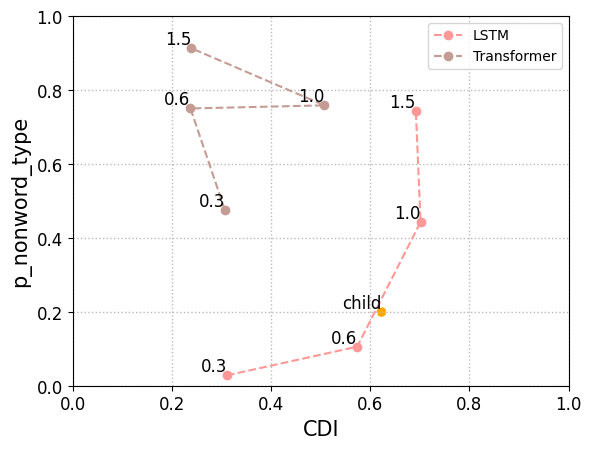

  model temp       CDI p_nonword_type type/token
0  LSTM  0.3  0.310911        0.02795   0.019024
0  LSTM  0.6  0.573597       0.105596   0.051813
0  LSTM  1.0  0.701478       0.442787   0.143892
0  LSTM  1.5  0.691926       0.743856    0.37865
         model temp       CDI p_nonword_type type/token
0  Transformer  0.3  0.307011       0.475254    0.09187
0  Transformer  0.6   0.23752        0.75016   0.116596
0  Transformer  1.0  0.507521       0.758601   0.243196
0  Transformer  1.5  0.238729       0.913459   0.446996


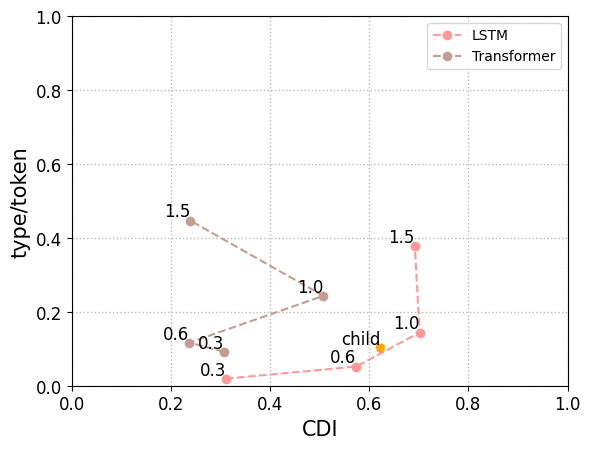

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_52574/4228762775.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame['slope'] = slope['slope'].tolist()
/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_52574/4228762775.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame['slope'] = slope['slope'].tolist()
/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_52574/4228762775.py:132: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

  model temp       CDI p_nonword_type type/token      slope
0  LSTM  0.3  0.310911        0.02795   0.019024 -68.102564
0  LSTM  0.6  0.573597       0.105596   0.051813  -8.461538
0  LSTM  1.0  0.701478       0.442787   0.143892  -5.115385
0  LSTM  1.5  0.691926       0.743856    0.37865  -4.474359
         model temp       CDI p_nonword_type type/token     slope
0  Transformer  0.3  0.307011       0.475254    0.09187 -7.333333
0  Transformer  0.6   0.23752        0.75016   0.116596 -7.423077
0  Transformer  1.0  0.507521       0.758601   0.243196 -8.179487
0  Transformer  1.5  0.238729       0.913459   0.446996 -4.576923


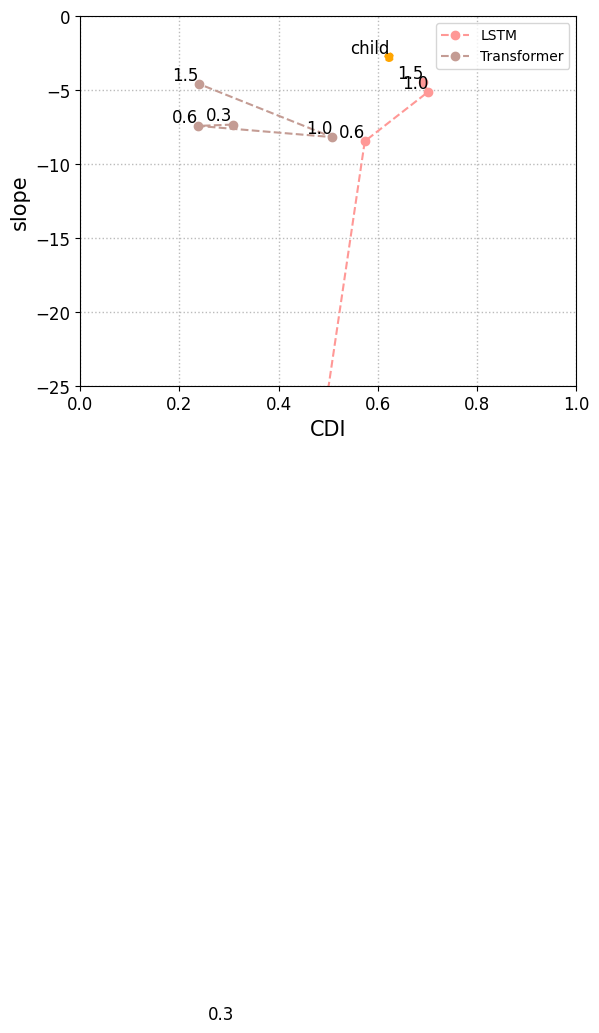

In [46]:
# match the slope with CDI
mean = True
train_set = "adult"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(score_all, metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(score_all, metric, name, train_set, mean)


metric = "slope"
para = slope_frame[slope_frame["train_set"] == train_set]
para = para.drop_duplicates()
temp_tradeoff(score_all, metric, name, train_set, mean, y_lim=[-25, 0], slope_frame=para)


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

  model temp       CDI p_nonword_type type/token
0  LSTM  0.3  0.310911        0.02795   0.019024
0  LSTM  0.6  0.573597       0.105596   0.051813
0  LSTM  1.0  0.701478       0.442787   0.143892
0  LSTM  1.5  0.691926       0.743856    0.37865
         model temp       CDI p_nonword_type type/token
0  Transformer  0.3  0.307011       0.475254    0.09187
0  Transformer  0.6   0.23752        0.75016   0.116596
0  Transformer  1.0  0.507521       0.758601   0.243196
0  Transformer  1.5  0.238729       0.913459   0.446996


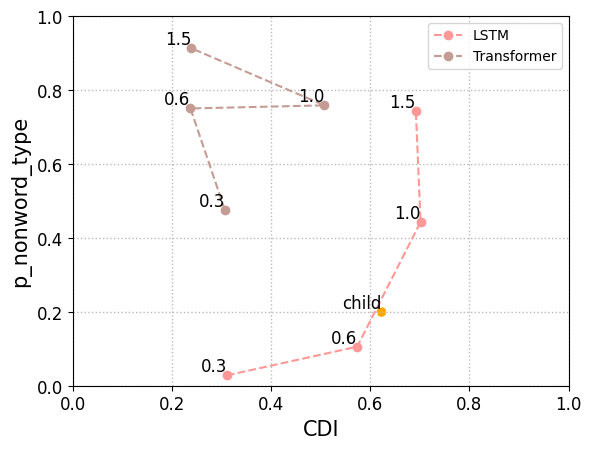

  model temp       CDI p_nonword_type type/token
0  LSTM  0.3  0.310911        0.02795   0.019024
0  LSTM  0.6  0.573597       0.105596   0.051813
0  LSTM  1.0  0.701478       0.442787   0.143892
0  LSTM  1.5  0.691926       0.743856    0.37865
         model temp       CDI p_nonword_type type/token
0  Transformer  0.3  0.307011       0.475254    0.09187
0  Transformer  0.6   0.23752        0.75016   0.116596
0  Transformer  1.0  0.507521       0.758601   0.243196
0  Transformer  1.5  0.238729       0.913459   0.446996


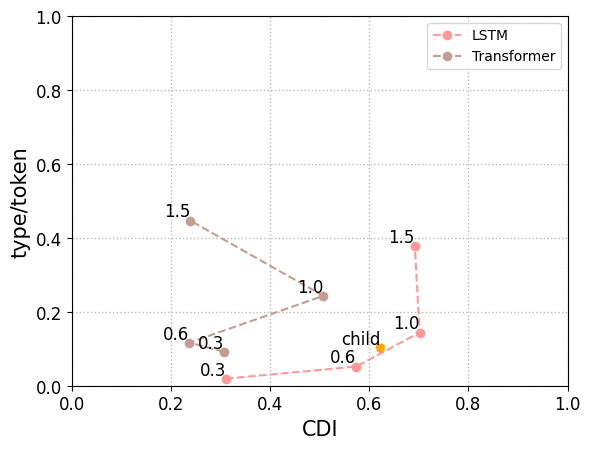

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_15153/4228762775.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame['slope'] = slope['slope'].tolist()
/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_15153/4228762775.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame['slope'] = slope['slope'].tolist()
/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_15153/4228762775.py:132: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

  model temp       CDI p_nonword_type type/token     slope
0  LSTM  0.3  0.310911        0.02795   0.019024 -7.628205
0  LSTM  0.6  0.573597       0.105596   0.051813 -6.948718
0  LSTM  1.0  0.701478       0.442787   0.143892 -4.961538
0  LSTM  1.5  0.691926       0.743856    0.37865 -5.153846
         model temp       CDI p_nonword_type type/token      slope
0  Transformer  0.3  0.307011       0.475254    0.09187 -20.807692
0  Transformer  0.6   0.23752        0.75016   0.116596 -18.987179
0  Transformer  1.0  0.507521       0.758601   0.243196  -8.935897
0  Transformer  1.5  0.238729       0.913459   0.446996  -8.487179


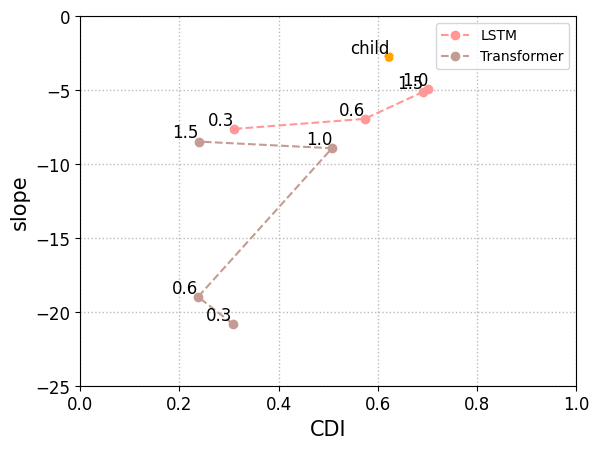

In [259]:
# match the slope with CDI
mean = True
train_set = "adult"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(score_all, metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(score_all, metric, name, train_set, mean)


metric = "slope"
para = slope_frame[slope_frame["train_set"] == train_set]
para = para.drop_duplicates()
temp_tradeoff(score_all, metric, name, train_set, mean, y_lim=[-25, 0], slope_frame=para)


In [36]:
# match the slope with CDI
mean = True
train_set = "adult"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, train_set, mean)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/500h/CDI/adult/unprompted/LSTM/BE/unprompted_0.3.csv'

In [37]:
# match the slope with CDI
mean = False
train_set = "adult"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, train_set, mean)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jliu/PycharmProjects/Lexical-benchmark/datasets/processed/500h/CDI/adult/unprompted/LSTM/BE/unprompted_0.3.csv'

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

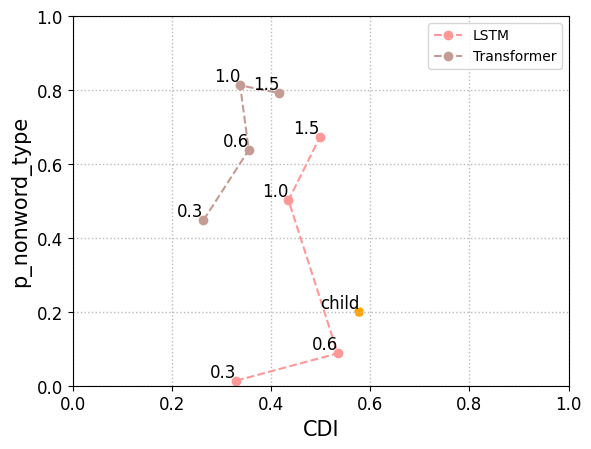

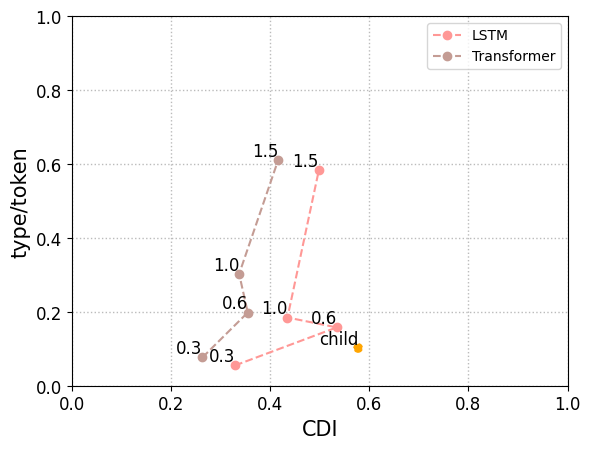

"\nmetric = 'slope'\nname = 'slope'\ntemp_tradeoff(metric,name,mean,[-25,0])\n\n"

In [92]:
# match the slope with CDI
mean = True
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, train_set, mean)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])

"""

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

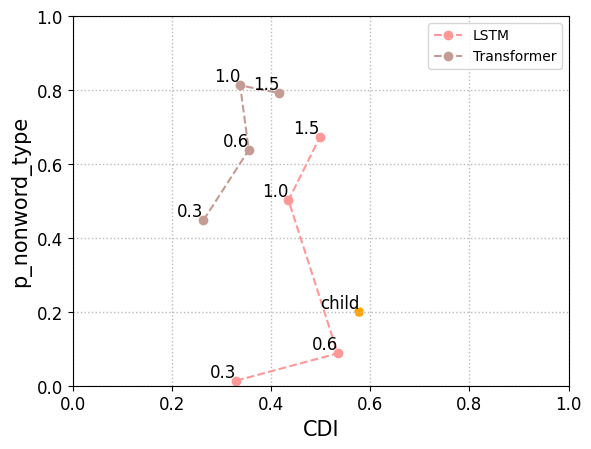

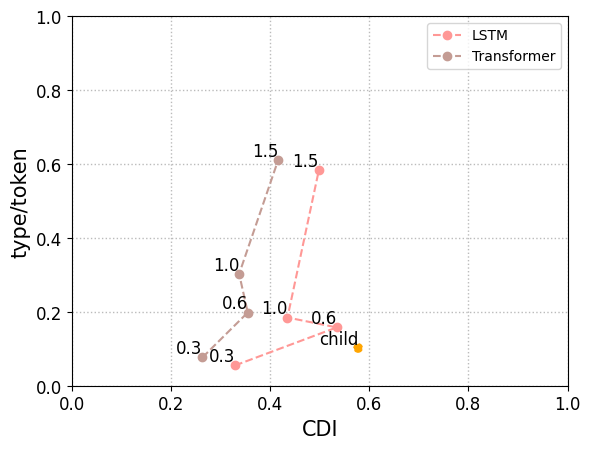

"\nmetric = 'slope'\nname = 'slope'\ntemp_tradeoff(metric,name,mean,[-25,0])\n\n"

In [91]:
# match the slope with CDI
mean = True
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, train_set, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, train_set, mean)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])

"""

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

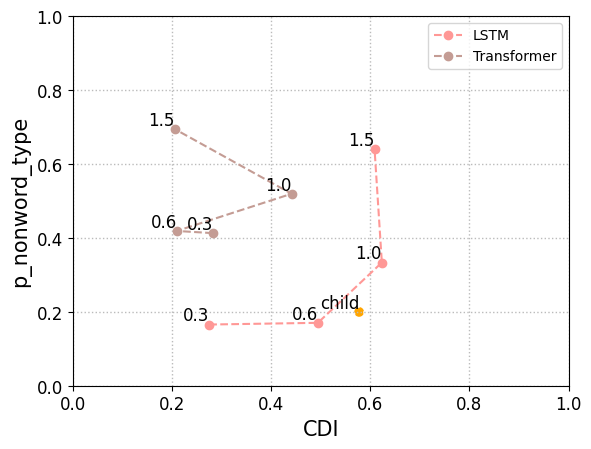

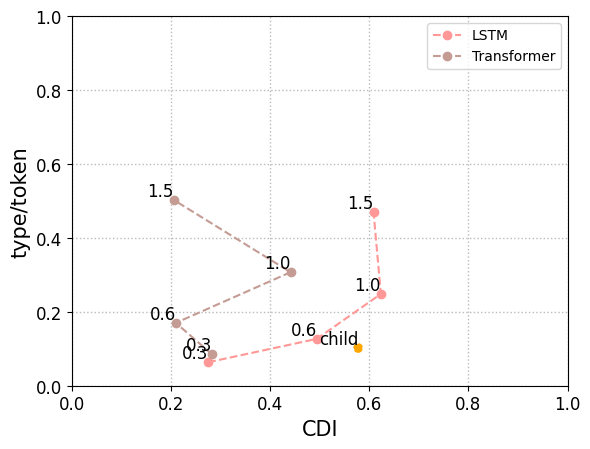

"\nmetric = 'slope'\nname = 'slope'\ntemp_tradeoff(metric,name,mean,[-25,0])\n"

In [58]:
# match the slope with CDI
mean = True
train_set = "adult"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean, train_set)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean, train_set)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

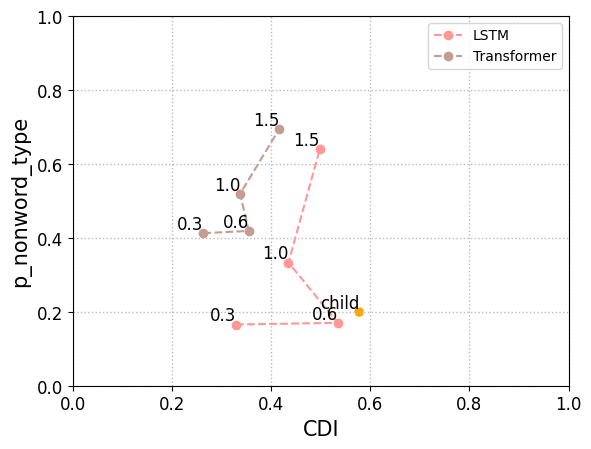

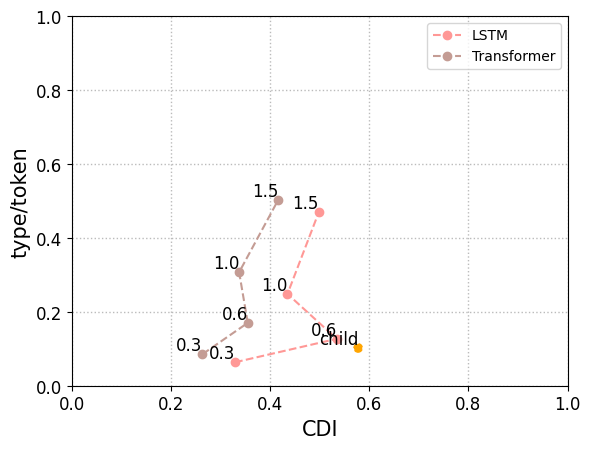

"\nmetric = 'slope'\nname = 'slope'\ntemp_tradeoff(metric,name,mean,[-25,0])\n"

In [60]:
# match the slope with CDI
mean = True
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean, train_set)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean, train_set)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

In [47]:
# match the slope with CDI
mean = False
train_set = "audiobook"
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean, train_set)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean, train_set)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean, train_set)
"""
metric = 'slope'
name = 'slope'
temp_tradeoff(metric,name,mean,[-25,0])
"""

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:47: FutureWarning: DataF

TypeError: temp_tradeoff() missing 1 required positional argument: 'mean'

In [10]:
# match the slope with CDI
mean = False
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean)


metric = "slope"
name = "slope"
temp_tradeoff(metric, name, mean, [-25, 0])

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)


ValueError: array must not contain infs or NaNs

/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: 1 if x > threshold else 0)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:48: FutureWarning: DataF

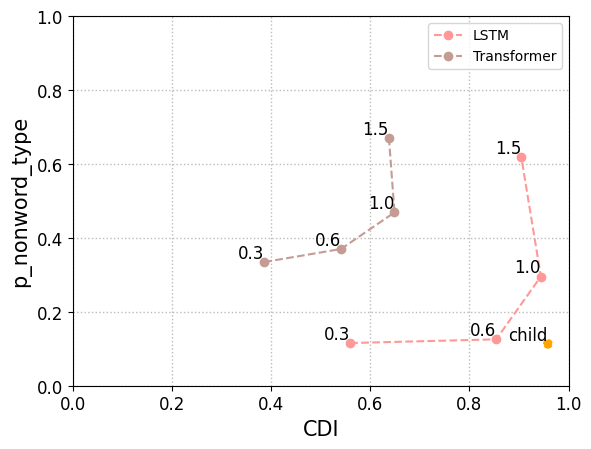

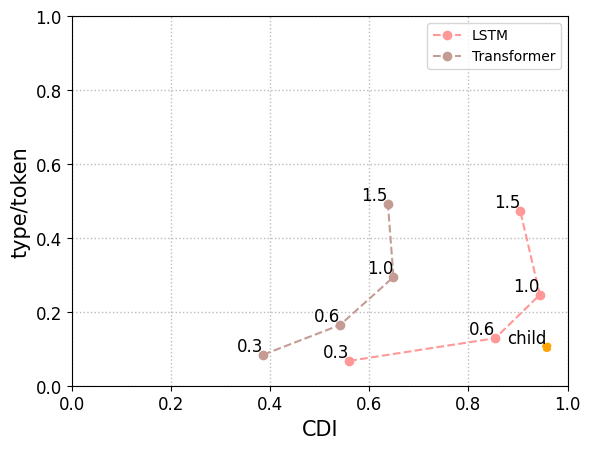

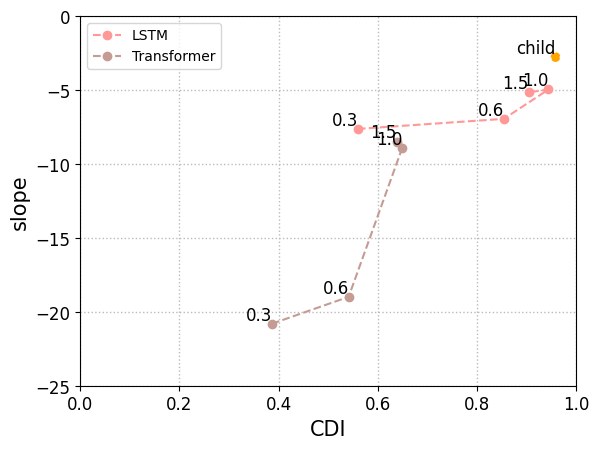

In [106]:
# match the slope with CDI
mean = False
score_all = get_score_all(lang, PROMPT, MODEL_lst, temp_lst, mean)

metric = "p_nonword_type"
name = "nword"
temp_tradeoff(metric, name, mean)


metric = "type/token"
name = "ttr"
temp_tradeoff(metric, name, mean)


metric = "slope"
name = "slope"
temp_tradeoff(metric, name, mean, [-25, 0])

# Case study

## scatter plot of different vocab distr

In [114]:
def load_count(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)
    return all_count


# load data recursively
def load_files(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)

    # divide into different types of sets
    gen_count = []
    unwanted_lst = ["train", "child", "adult"]
    for tc in all_count:
        if tc.name not in unwanted_lst:
            gen_count.append(tc)
        if tc.name == "train":
            ref_count = tc
        else:
            pass
    return all_count, ref_count, gen_count

In [116]:
def line_plot(data, fig_path: str, prompt_type: str, model: str, xlog=True, ylim=[0, 1]):
    """Generic line plotting function; data is a dictionnary associating a name with a dataframe with two columns
    (the first one for x, the second one for y)
    """
    # plt.figure(figsize=(10, 5))  # Set the size of the plot

    for key in data:
        df = data[key]
        xname = df.columns[0]
        yname = df.columns[1]
        aggregated_df = df.groupby(xname)[yname].mean().reset_index()
        if key == "ind" or key == "ood":
            linetyle = "-"
            linewidth = 3.5
        else:
            linetyle = "-"
            linewidth = 3
        plt.plot(aggregated_df[xname], aggregated_df[yname], linewidth=linewidth, linestyle=linetyle, label=key, color=color_dict[key])

    plt.xlabel(xname, fontsize=20)  # Label for the x-axis
    plt.ylabel(yname, fontsize=20)  # Label for the y-axis
    plt.ylim(ylim)
    # plt.axhline(y=0, color='red', linestyle='--',linewidth=3.5, label='y = 0')
    if xlog:
        plt.xscale("log")


def tc_plot_miss_oov_rates(ref_count: TokenCount, gen_count_list: list, set_name: str, fig_path: str, prompt_type: str, model: str, groupbin=50):
    """
     Plots three curves regarding missing words and oovs

    :param ref_count: a reference TokenCount
    :param gen_count_list: a list of generated or test TokenCount
    :param groupbin:
    :return: dataframe containing different scores
    """
    pmiss = {}
    poov = {}

    for gen_count in gen_count_list:
        msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=groupbin)
        if set_name == "pmiss":
            pmiss[gen_count.name] = msc[["medcount", "pmiss"]]
            line_plot(pmiss, fig_path + "M.png", prompt_type, model)
        elif set_name == "oov":
            poov[gen_count.name] = osc[["medcount", "poov"]]
            line_plot(poov, fig_path + "O.png", prompt_type, model)
    return msc, osc, nsc

In [11]:
def scatter_hist_shade(ref_count: TokenCount, gen_count: TokenCount, model: str, ax, ax_histx, ax_histy, color_dict, num, log, bins=100, alpha_val=0.5):
    # Scatter plot with varying transparency (alpha) and edge color
    newdf = pd.merge(ref_count.df[["word", "count"]], gen_count.df[["word", "count"]], on="word", how="outer")
    newdf.set_index("word", inplace=True)
    newdf.columns = ["ref_count", "gen_count"]
    withoutoovdf = newdf[newdf["ref_count"].notna()]

    # Vary the transparency for each dataset
    ax.scatter(withoutoovdf["ref_count"], withoutoovdf["gen_count"], color=color_dict[num], alpha=alpha_val, label=f"{num}x")

    maxx = max(withoutoovdf["gen_count"])
    ax.plot([0, maxx], [0, maxx], color="r", alpha=1)

    # Plot the missing word rates by frequency
    msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=50)

    aggregated_df_miss = msc.groupby("medcount")["pmiss"].mean().reset_index()
    ax_histx.plot(aggregated_df_miss["medcount"], aggregated_df_miss["pmiss"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histx.invert_yaxis()

    aggregated_df_oov = osc.groupby("medcount")["poov"].mean().reset_index()
    ax_histy.plot(aggregated_df_oov["poov"], aggregated_df_oov["medcount"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histy.invert_xaxis()

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
        # ax_histx.set_yscale("log")
        ax_histy.set_yscale("log")
        ax_histx.set_xscale("log")
        # ax_histy.set_xscale("log")

    # Set axis range for histograms (side bars)
    ax_histx.set_ylim(0, 1)  # Set x-axis range for the top histogram
    ax_histy.set_xlim(0, 1)  # Set y-axis range for the left histogram
    # save the figure to the required directory
    plt.savefig(Path(fig_ROOT) / f"distr_{model[:5]}_{gen_count.name}.png", dpi=300, bbox_inches="tight")
    return newdf, maxx


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['correct'].fillna(newdf['ref_correct'], inplace=True)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

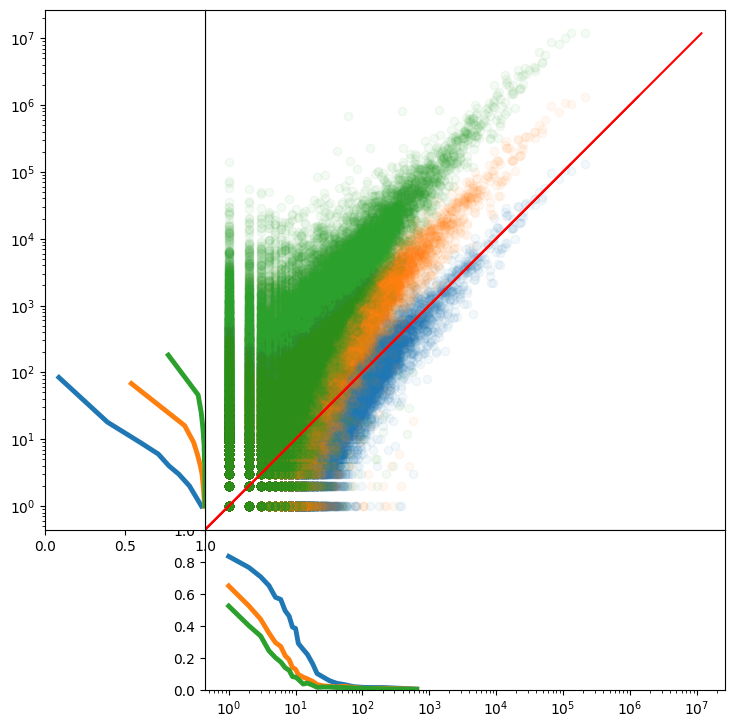

In [12]:
filename_lst = ["1", "10", "100"]
prompt_type = "unprompted"
color_dict = {
    "1": "#1f77b4",  # Blue
    "10": "#ff7f0e",  # Orange
    "100": "#2ca02c",  # Green
}

log = True
model = "LSTM"

# Create the figure once, outside the loop
fig = plt.figure(figsize=(8, 8))

# Axes locations for subplots, we will reuse them across the loop
left, width = 0.3, 0.65
bottom, height = 0.1, 0.65
spacing = 0

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom - spacing - 0.2, width, 0.2]
rect_histy = [left - spacing - 0.2, bottom, 0.2, height]

# Create ax once, and reuse for each dataset
ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

diag_lines = {}
# Loop over each dataset
for idx, filename in enumerate(filename_lst):
    freq_ROOT = f"{ROOT}/datasets/processed/freq/{prompt_type}_{model}_400_{filename}/"
    all_count, ref_count, gen_count_lst = load_files(freq_ROOT)

    # Set alpha transparency value: Start with 0.8 and reduce for each subsequent dataset
    alpha_val = 0.05
    newdf, maxx = scatter_hist_shade(ref_count, gen_count_lst[0], model, ax, ax_histx, ax_histy, color_dict, filename, log, alpha_val=alpha_val)

# Add legend and display the figure

plt.show()


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['correct'].fillna(newdf['ref_correct'], inplace=True)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

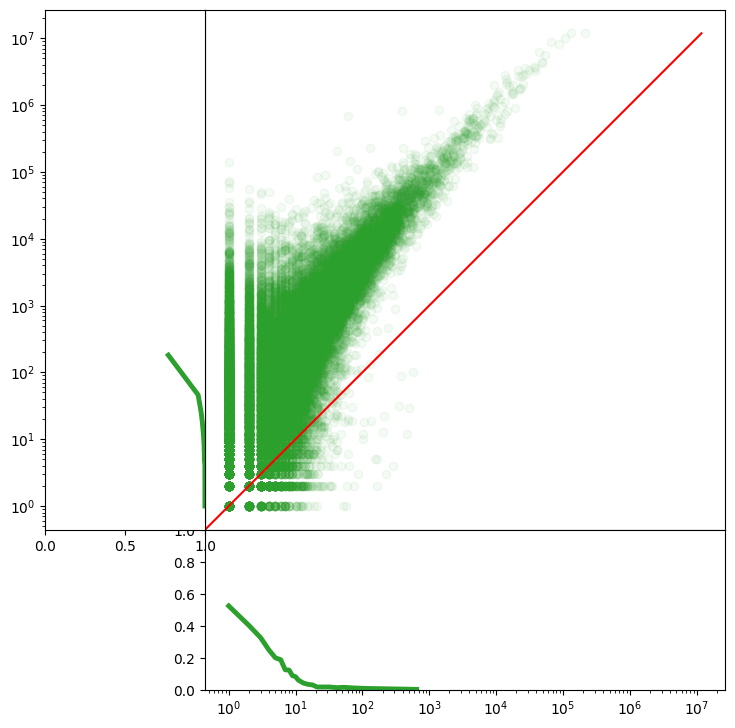

In [125]:
filename_lst = ["100"]
prompt_type = "unprompted"
color_dict = {
    "1": "#1f77b4",  # Blue
    "10": "#ff7f0e",  # Orange
    "100": "#2ca02c",  # Green
}

log = True
model = "LSTM"

# Create the figure once, outside the loop
fig = plt.figure(figsize=(8, 8))

# Axes locations for subplots, we will reuse them across the loop
left, width = 0.3, 0.65
bottom, height = 0.1, 0.65
spacing = 0

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom - spacing - 0.2, width, 0.2]
rect_histy = [left - spacing - 0.2, bottom, 0.2, height]

# Create ax once, and reuse for each dataset
ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

# Loop over each dataset
for idx, filename in enumerate(filename_lst):
    freq_ROOT = f"{ROOT}/datasets/processed/freq/{prompt_type}_{model}_400_{filename}/"
    all_count, ref_count, gen_count_lst = load_files(freq_ROOT)

    # Set alpha transparency value: Start with 0.8 and reduce for each subsequent dataset
    alpha_val = 0.05
    scatter_hist_shade(ref_count, gen_count_lst[0], model, ax, ax_histx, ax_histy, color_dict, filename, log, alpha_val=alpha_val)

# Add legend and display the figure
# ax.legend(loc='best')
plt.show()


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['correct'].fillna(newdf['ref_correct'], inplace=True)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

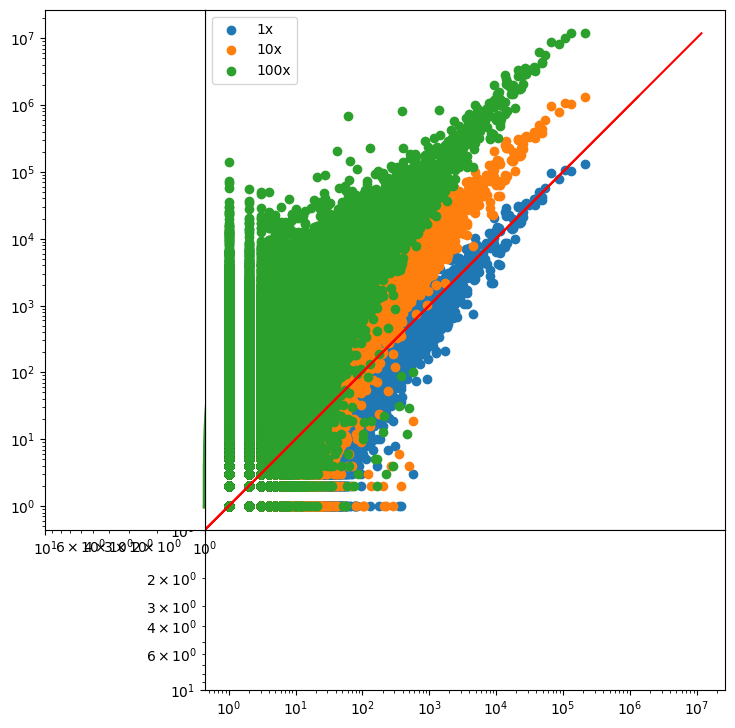

In [134]:
filename_lst = ["1", "10", "100"]
prompt_type = "unprompted"
color_dict = {
    "1": "#1f77b4",  # Blue
    "10": "#ff7f0e",  # Orange
    "100": "#2ca02c",  # Green
}

log = True
model = "LSTM"

# Create the figure once, outside the loop
fig = plt.figure(figsize=(8, 8))

# Axes locations for subplots, we will reuse them across the loop
left, width = 0.3, 0.65
bottom, height = 0.1, 0.65
spacing = 0

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom - spacing - 0.2, width, 0.2]
rect_histy = [left - spacing - 0.2, bottom, 0.2, height]

# Create ax once, and reuse for each dataset
ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

# Loop over each dataset
for idx, filename in enumerate(filename_lst):
    freq_ROOT = f"{ROOT}/datasets/processed/freq/{prompt_type}_{model}_400_{filename}/"
    all_count, ref_count, gen_count_lst = load_files(freq_ROOT)

    # Set alpha transparency value: Start with 0.8 and reduce for each subsequent dataset
    alpha_val = 1
    scatter_hist_shade(ref_count, gen_count_lst[0], model, ax, ax_histx, ax_histy, color_dict, filename, log, alpha_val=alpha_val)

# Add legend and display the figure
ax.legend(loc="best")
plt.show()
